# NBXX:  Revised population synthesis

This notebook holds evaluations of the two population synthesis methods, a linear interpolator and a physically-motivated analytical model for wind pile-ups.

In [1]:
nb_id = "xx"

## Setup

In [2]:
from pathlib import Path
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

import astropy.units as u
import astropy.constants as ct
from astropy.cosmology import WMAP9 as cosmo
from scipy.interpolate import interp1d

from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm

import mesa_reader as mr

import sys
sys.path.append('..')
from src.binary import eggleton_rl1_radius, a_from_p, marchant_l2_radius
from src.util import DATA_DIR, MESA_DATA_DIR, build_logbump35_cmap, savefig_base
from src.constants import Z_SUN
FIGURE_FOLDER = Path(f'../figures/nb{nb_id}')
FIGURE_FOLDER.mkdir(parents=True, exist_ok=True)

OUTPUT_FOLDER = DATA_DIR / 'nb_output' / f'nb{nb_id}'
OUTPUT_FOLDER.mkdir(parents=True, exist_ok=True)
plt.style.use('./plotstyle.mplstyle')
pd.set_option('display.max_columns', None)

In [3]:
def savefig(fig, fname):
    savefig_base(fig, fname, nb_id, FIGURE_FOLDER)

In [4]:
from src.popsynth import PMZLinearInterpolator, PMZWindPileupModel, get_complete_core_props_df, plot_pmz_mass_time_diagnostic, cross_validate_pmz, plot_pmz_cv_diagnostic, plot_pmz_interpolator_fit

In [5]:
core_props_df = get_complete_core_props_df(DATA_DIR/'00_fiducial_core_props_df.h5')

In [6]:
interpolator = PMZLinearInterpolator(core_props_df, var='m_f', cut_non_he_depl=True)

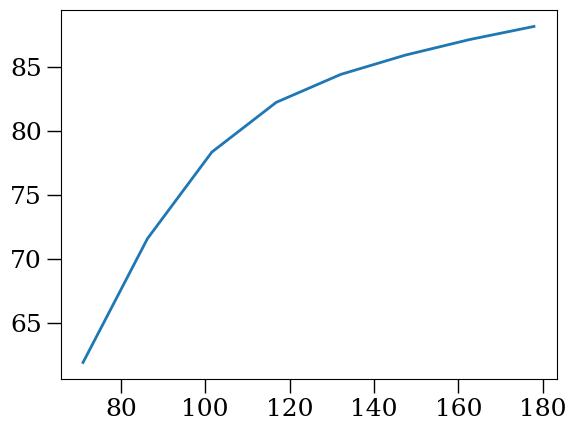

In [7]:
mi = np.linspace(10, 300, 20)
vec_get_far = np.vectorize(interpolator.get_var)
mf = vec_get_far(mi, 1, 0.02)
plt.plot(mi, mf)

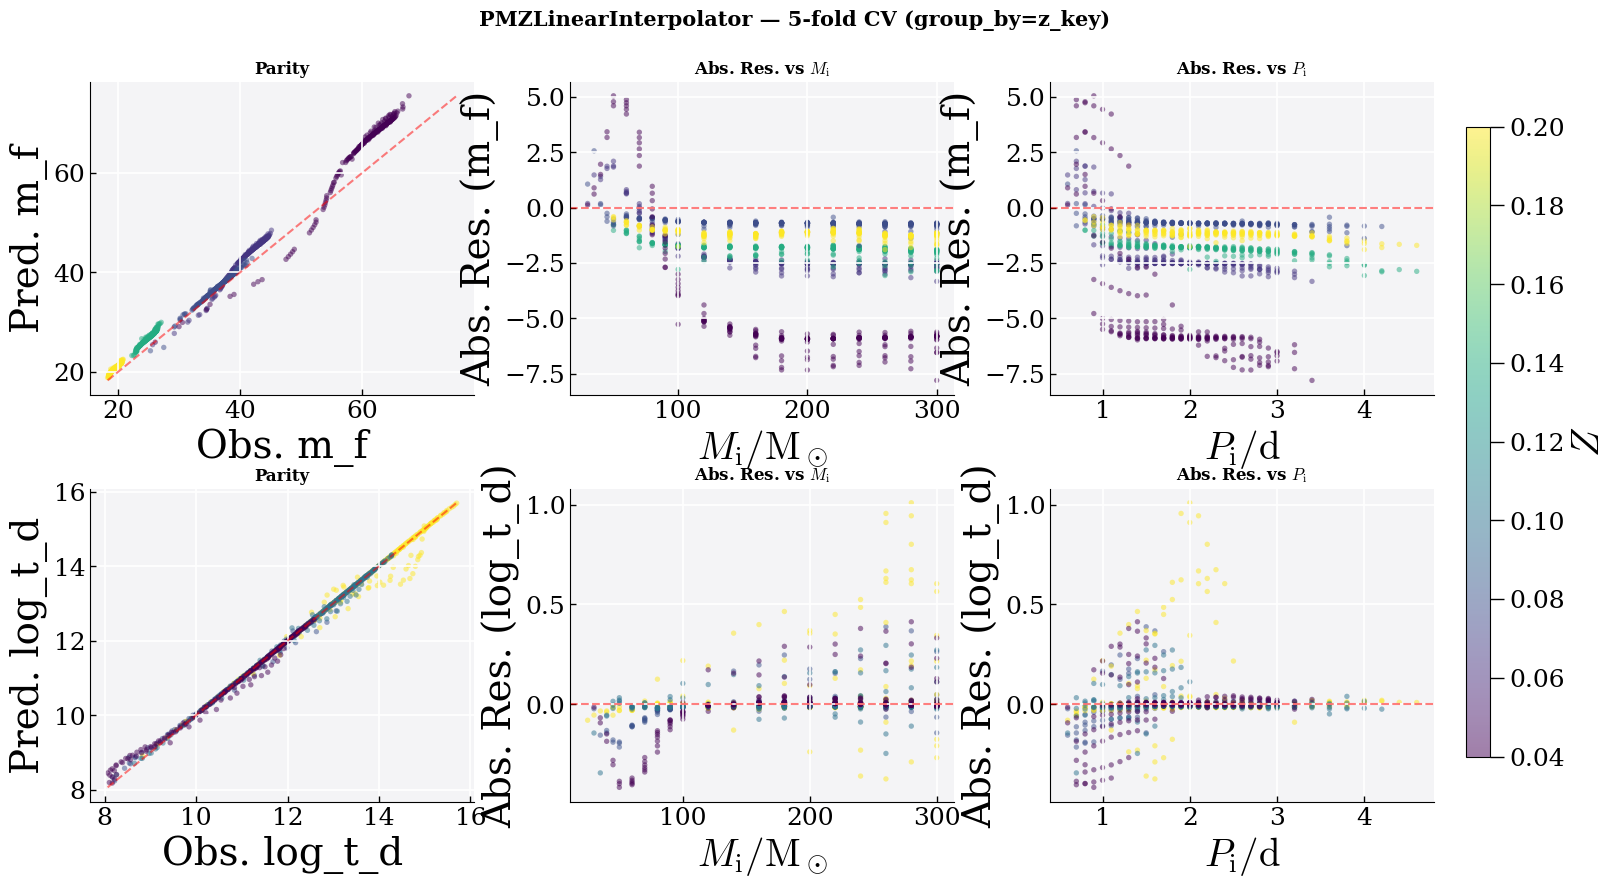

In [8]:
fig, axs, oofs = plot_pmz_cv_diagnostic(
    PMZLinearInterpolator, core_props_df,
    mass_var="m_f", time_var="log_t_d",
    k=5, group_by="z_key",          # leave-one-Z-out
    cut_non_he_depl=True,
)


TODO
* k-fold for some reason cannot produce residuals
* current coloring by initial Porb is not good

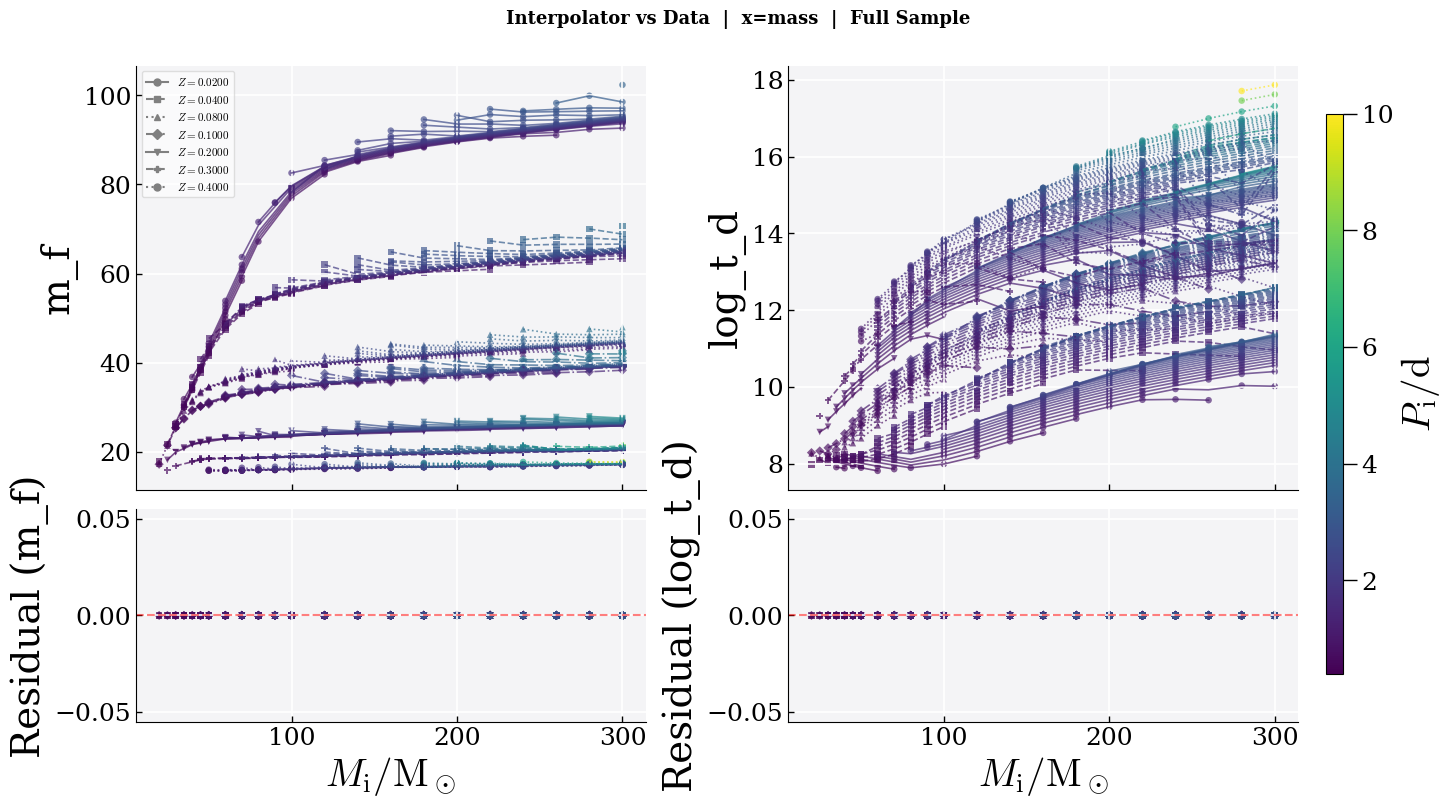

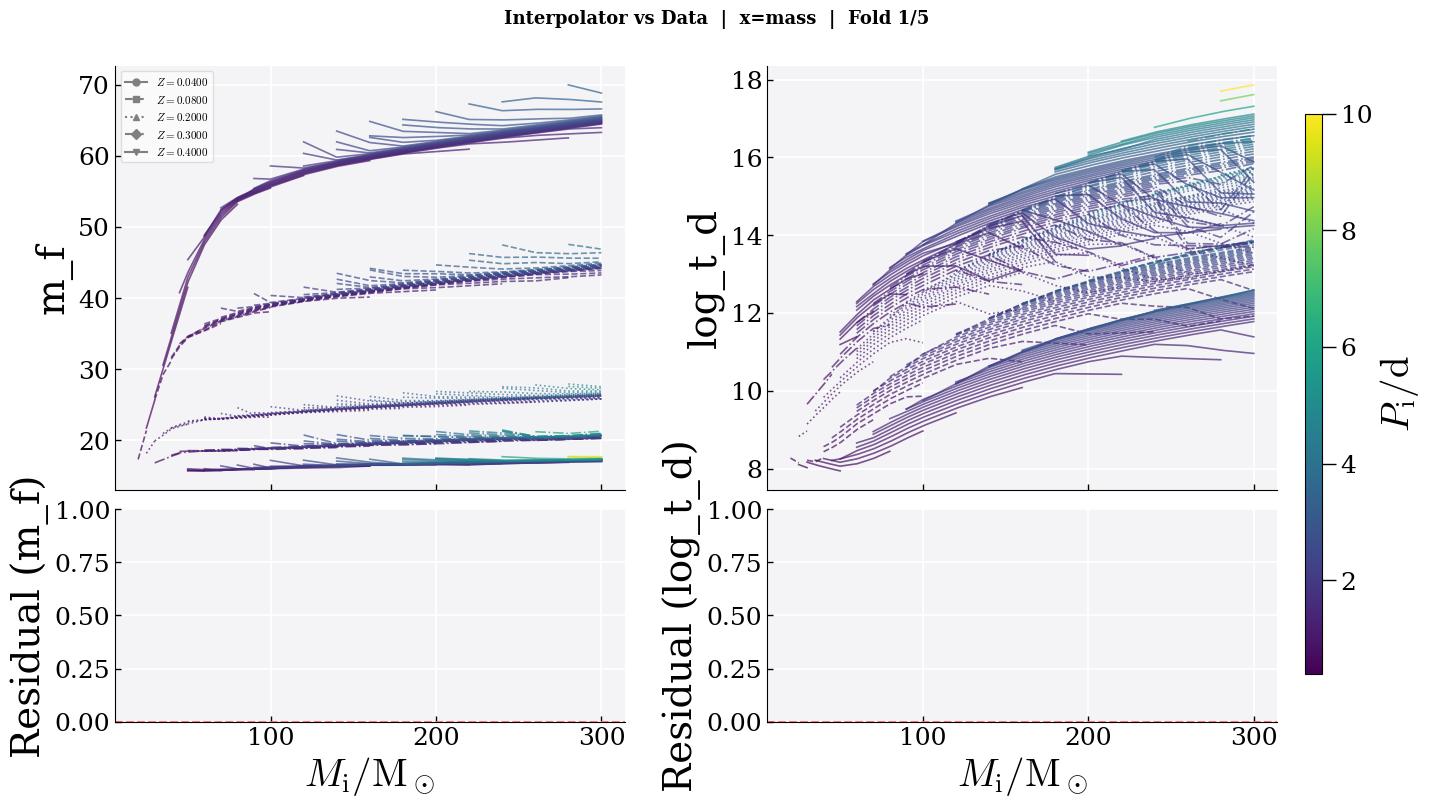

KeyboardInterrupt: 

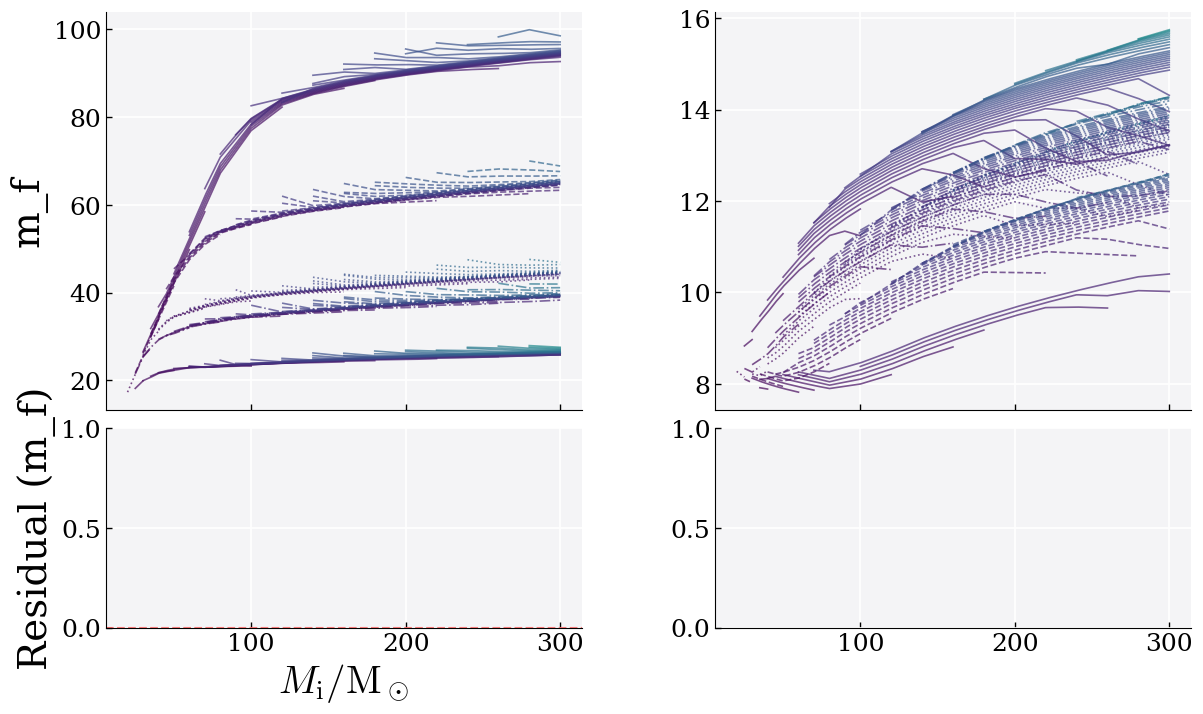

In [9]:
# Whole sample — one figure
figs = plot_pmz_interpolator_fit(PMZLinearInterpolator, core_props_df, cut_non_he_depl=True)
fig, axs = figs[0]

# 5-fold CV — five figures
figs = plot_pmz_interpolator_fit(
    PMZLinearInterpolator, core_props_df,
    k=5, group_by="z_key",
    cut_non_he_depl=True,
)
for fold_idx, (fig, axs) in enumerate(figs):
    fig.savefig(f"fold_{fold_idx}.png")


In [8]:
analytical = PMZWindPileupModel(core_props_df, 'm_f')

In [12]:
analytical.fit()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha         0.215  0.010   0.197    0.233      0.000    0.000    1223.0   
beta          4.625  0.048   4.537    4.716      0.002    0.001     993.0   
log_mdot_ref -9.012  0.050  -9.114   -8.924      0.002    0.001     996.0   
gamma         2.061  0.025   2.014    2.110      0.001    0.000     980.0   
delta        -0.198  0.006  -0.210   -0.186      0.000    0.000    1636.0   

              ess_tail  r_hat  
alpha           2010.0    1.0  
beta            1447.0    1.0  
log_mdot_ref    1472.0    1.0  
gamma           1453.0    1.0  
delta           2080.0    1.0  

Convergence [m_f]: max r_hat=1.0000, min ESS=980 — OK


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

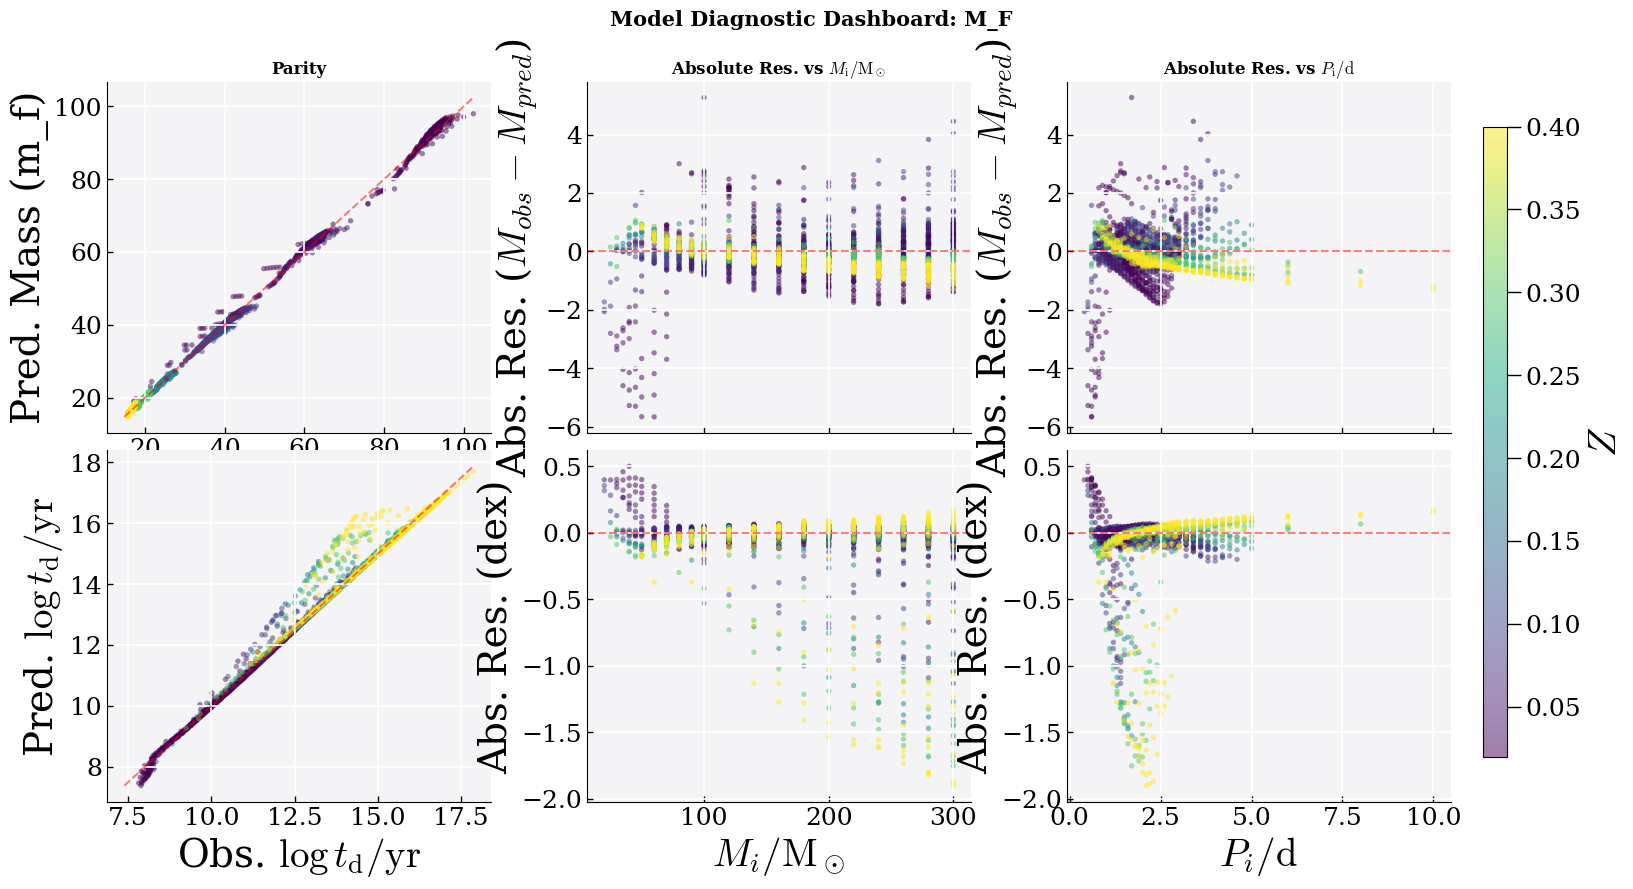

(<Figure size 1600x900 with 7 Axes>,
 array([[<Axes: title={'center': 'Parity'}, ylabel='Pred. Mass (m_f)'>,
         <Axes: title={'center': 'Absolute Res. vs $M_\\mathrm{i}/\\mathrm{M}_\\odot$'}, ylabel='Abs. Res. ($M_{obs} - M_{pred}$)'>,
         <Axes: title={'center': 'Absolute Res. vs $P_\\mathrm{i}/\\mathrm{d}$'}, ylabel='Abs. Res. ($M_{obs} - M_{pred}$)'>],
        [<Axes: xlabel='Obs. $\\log t_\\mathrm{d} / \\mathrm{yr}$', ylabel='Pred. $\\log t_\\mathrm{d} / \\mathrm{yr}$'>,
         <Axes: xlabel='$M_{i}/\\mathrm{M}_\\odot$', ylabel='Abs. Res. (dex)'>,
         <Axes: xlabel='$P_{i}/\\mathrm{d}$', ylabel='Abs. Res. (dex)'>]],
       dtype=object))

In [18]:
analytical.plot_diagnostic()

(<Figure size 1600x700 with 3 Axes>,
 (<Axes: title={'center': '$M_\\mathrm{i}/\\mathrm{M}_\\odot$ vs $M_\\mathrm{f}/\\mathrm{M}_\\odot$'}, xlabel='$M_\\mathrm{i}/\\mathrm{M}_\\odot$', ylabel='$M_\\mathrm{f}/\\mathrm{M}_\\odot$'>,
  <Axes: title={'center': '$P_\\mathrm{i}/\\mathrm{d}$ vs $M_\\mathrm{f}/\\mathrm{M}_\\odot$'}, xlabel='$P_\\mathrm{i}/\\mathrm{d}$', ylabel='$M_\\mathrm{f}/\\mathrm{M}_\\odot$'>))

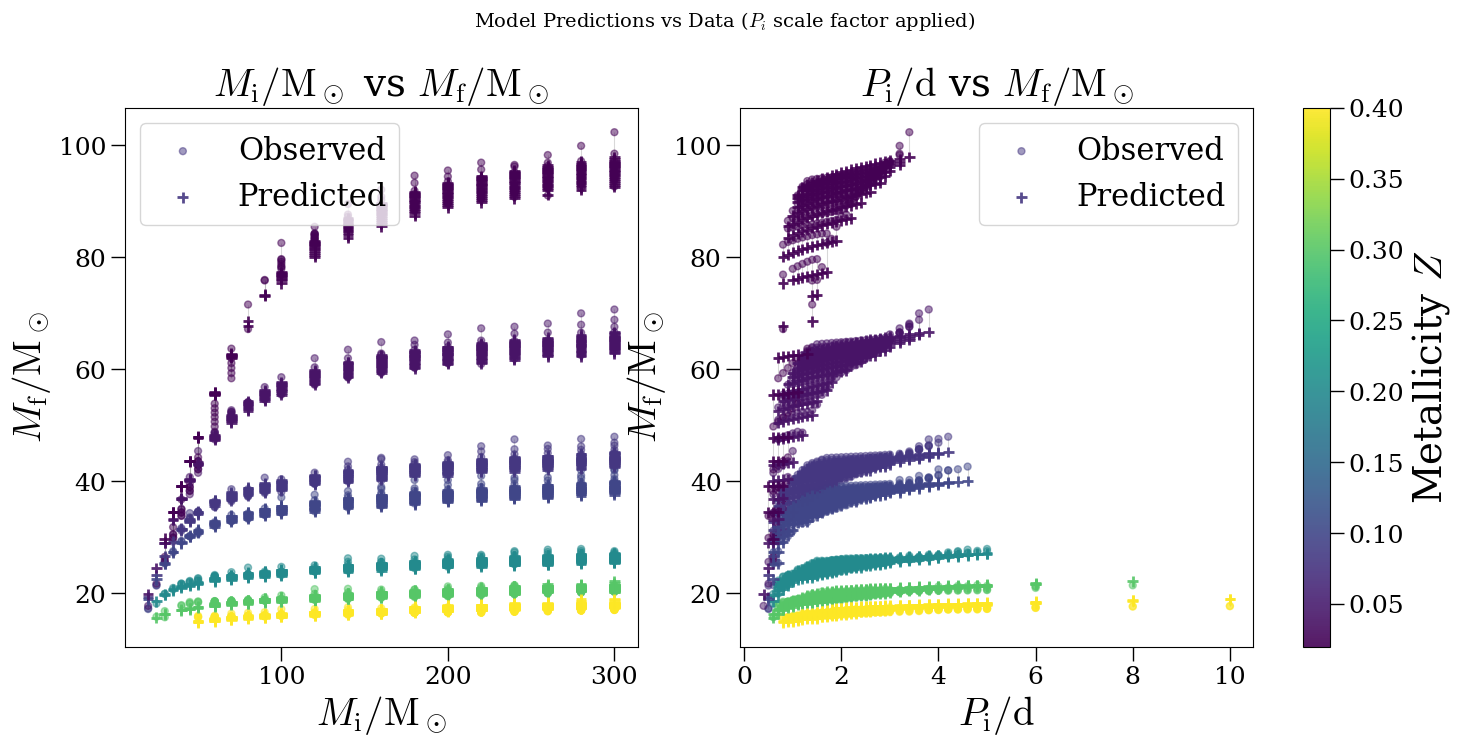

In [19]:
analytical.plot_relationship(y_var='m_f')      # Initial Mass vs Final Mass

# The function handles the necessary transformations and uses the posterior medians to 
# show how well the model "line" tracks the underlying data points. For $a_f$, it only 
# plots the predicted values as $a_f$ is typically a derived property rather than a 
# direct observation in the input dataframe.

(<Figure size 1600x700 with 3 Axes>,
 (<Axes: title={'center': '$M_\\mathrm{i}/\\mathrm{M}_\\odot$ vs $A_\\mathrm{f}/\\mathrm{R}_\\odot$'}, xlabel='$M_\\mathrm{i}/\\mathrm{M}_\\odot$', ylabel='$A_\\mathrm{f}/\\mathrm{R}_\\odot$'>,
  <Axes: title={'center': '$P_\\mathrm{i}/\\mathrm{d}$ vs $A_\\mathrm{f}/\\mathrm{R}_\\odot$'}, xlabel='$P_\\mathrm{i}/\\mathrm{d}$', ylabel='$A_\\mathrm{f}/\\mathrm{R}_\\odot$'>))

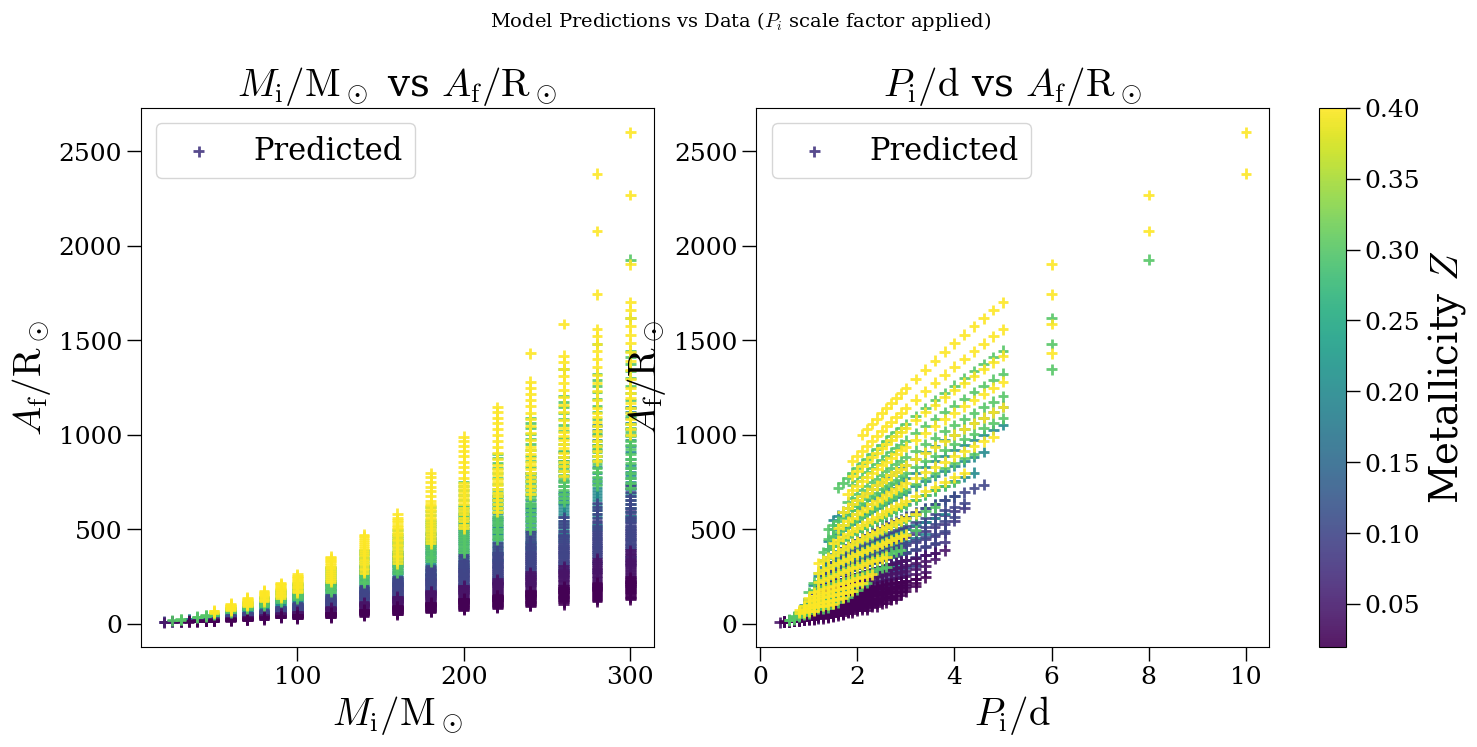

In [15]:
analytical.plot_relationship(y_var='a_f')      # Initial Mass vs Final Semi-major Axis


(<Figure size 1600x700 with 3 Axes>,
 (<Axes: title={'center': '$M_\\mathrm{i}/\\mathrm{M}_\\odot$ vs $\\log t_\\mathrm{d}/\\mathrm{yr}$'}, xlabel='$M_\\mathrm{i}/\\mathrm{M}_\\odot$', ylabel='$\\log t_\\mathrm{d}/\\mathrm{yr}$'>,
  <Axes: title={'center': '$P_\\mathrm{i}/\\mathrm{d}$ vs $\\log t_\\mathrm{d}/\\mathrm{yr}$'}, xlabel='$P_\\mathrm{i}/\\mathrm{d}$', ylabel='$\\log t_\\mathrm{d}/\\mathrm{yr}$'>))

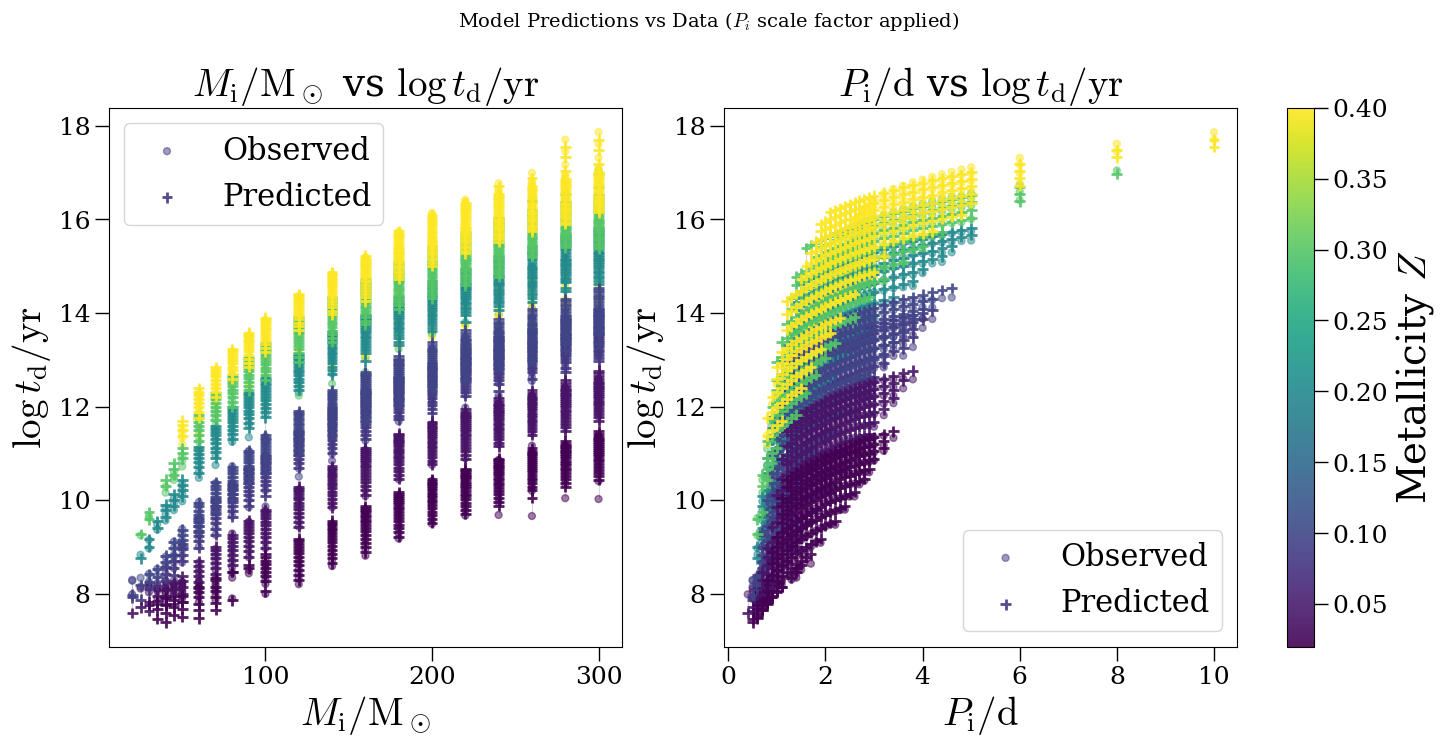

In [16]:
analytical.plot_relationship(y_var='log_t_d')  # Initial Mass vs Delay Time

### Delay time test

In [9]:
logtd_analytical = PMZWindPileupModel(core_props_df, 'log_t_d', use_alt_mf_map=True)

In [10]:
logtd_analytical.fit()

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

There were 141 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha         0.576  0.090   0.420    0.770      0.004    0.004     596.0   
beta          4.930  0.227   4.499    5.349      0.008    0.005     820.0   
log_mdot_ref -9.138  0.274  -9.670   -8.639      0.009    0.006    1022.0   
gamma         2.089  0.117   1.879    2.318      0.004    0.003     823.0   
delta        -0.002  0.002  -0.005   -0.000      0.000    0.000    1750.0   
eta           0.670  0.795   0.000    2.206      0.026    0.028     862.0   
delta_alpha   0.124  0.431  -0.493    0.966      0.014    0.026    1229.0   

              ess_tail  r_hat  
alpha            625.0   1.01  
beta            1102.0   1.00  
log_mdot_ref    1545.0   1.00  
gamma           1089.0   1.00  
delta           1363.0   1.00  
eta              811.0   1.00  
delta_alpha     1029.0   1.00  

Convergence [log_t_d]: max r_hat=1.0100, min ESS=596 — WARNING: check chains


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

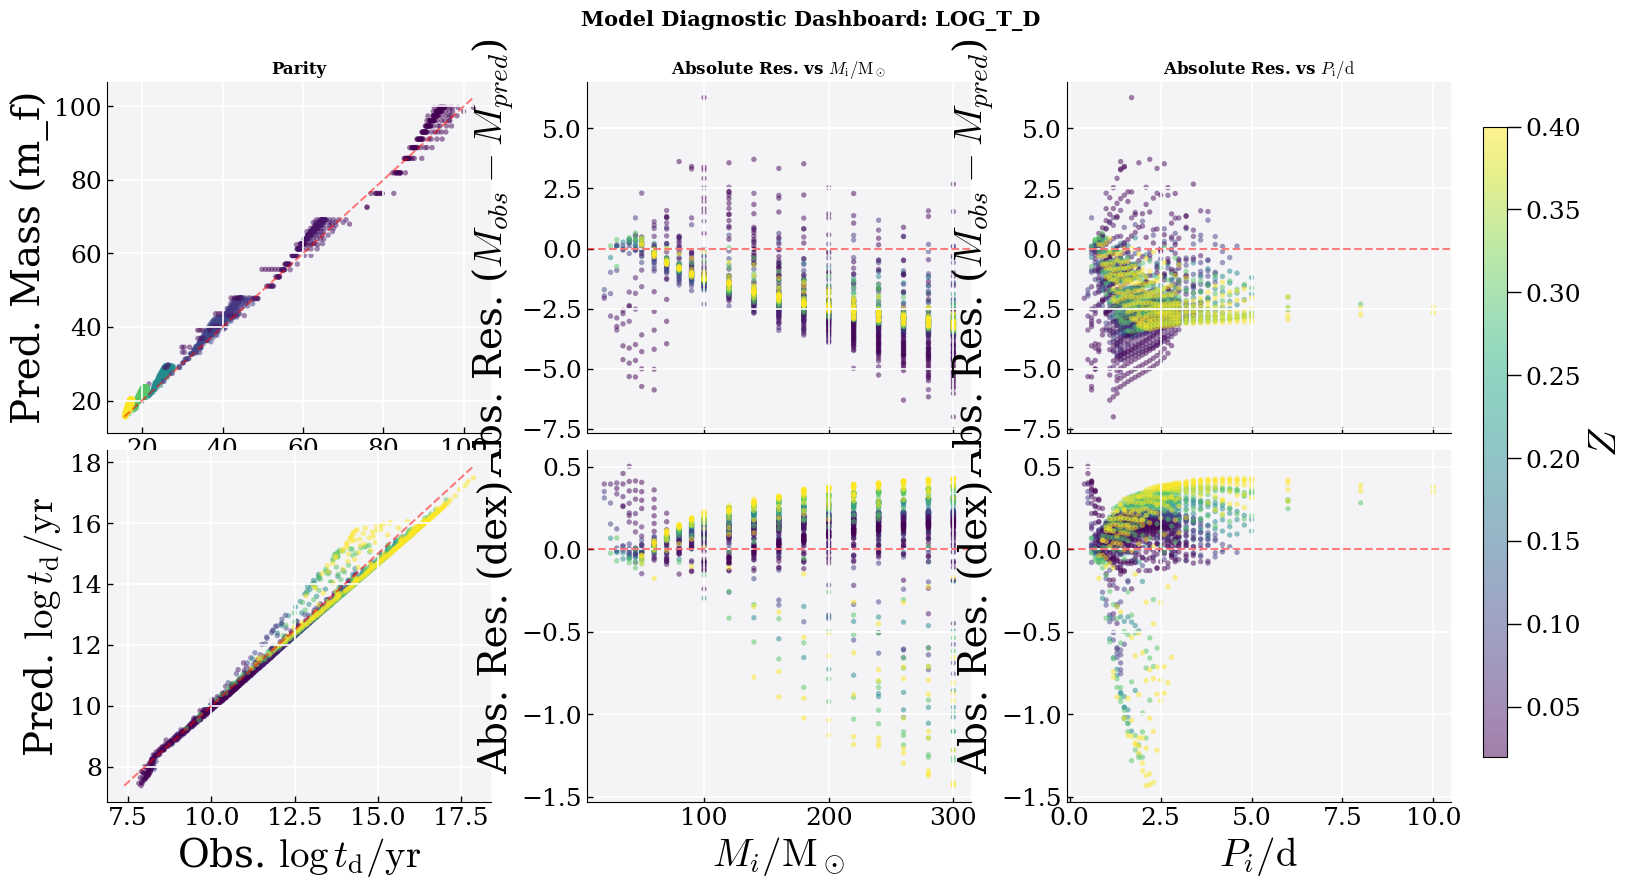

(<Figure size 1600x900 with 7 Axes>,
 array([[<Axes: title={'center': 'Parity'}, ylabel='Pred. Mass (m_f)'>,
         <Axes: title={'center': 'Absolute Res. vs $M_\\mathrm{i}/\\mathrm{M}_\\odot$'}, ylabel='Abs. Res. ($M_{obs} - M_{pred}$)'>,
         <Axes: title={'center': 'Absolute Res. vs $P_\\mathrm{i}/\\mathrm{d}$'}, ylabel='Abs. Res. ($M_{obs} - M_{pred}$)'>],
        [<Axes: xlabel='Obs. $\\log t_\\mathrm{d} / \\mathrm{yr}$', ylabel='Pred. $\\log t_\\mathrm{d} / \\mathrm{yr}$'>,
         <Axes: xlabel='$M_{i}/\\mathrm{M}_\\odot$', ylabel='Abs. Res. (dex)'>,
         <Axes: xlabel='$P_{i}/\\mathrm{d}$', ylabel='Abs. Res. (dex)'>]],
       dtype=object))

In [12]:
logtd_analytical.plot_diagnostic()

## Evaluation

In [11]:
from src.eval import run_test_suite

In [12]:
working_che_core_props_df = core_props_df[core_props_df.is_che & core_props_df.is_He_depleted]

In [13]:
structured_configs = [
                {'name': 'Stride 1',                'm_zams': 1, 'p_spin_zams': 1, 'z': 1},
                #{'name': 'Stride 2 (P)',            'm_zams': 1, 'p_spin_zams': 2, 'z': 1},
                {'name': 'Stride 2 (P, M)',         'm_zams': 2, 'p_spin_zams': 2, 'z': 1},
            # {'name': 'Stride 3 (P)',            'm_zams': 2, 'p_spin_zams': 3, 'z': 1},
                {'name': 'Stride 3 (P, M)',         'm_zams': 3, 'p_spin_zams': 3, 'z': 1},
            # {'name': 'Stride 4 (P)',            'm_zams': 3, 'p_spin_zams': 4, 'z': 1},
                {'name': 'Stride 4 (P, M)',         'm_zams': 4, 'p_spin_zams': 4, 'z': 1},
                {'name': 'Stride 5 (P, M)',         'm_zams': 5, 'p_spin_zams': 5, 'z': 1},
                {'name': 'Stride 6 (P, M)',         'm_zams': 6, 'p_spin_zams': 6, 'z': 1},
                {'name': 'Stride 7 (P, M)',         'm_zams': 7, 'p_spin_zams': 7, 'z': 1},
                {'name': 'Stride 8 (P, M)',         'm_zams': 8, 'p_spin_zams': 8, 'z': 1},
                {'name': 'Stride 6 (P, M) + 2 (Z)',         'm_zams': 6, 'p_spin_zams': 6, 'z': 2},
                {'name': 'Stride 6 (P, M) + 3 (Z)',         'm_zams': 6, 'p_spin_zams': 6, 'z': 3},
            ]

In [14]:
train_fracs = [1.0, 0.75, 0.5, 0.25, 0.1, 0.05, 0.025, 0.01]

In [15]:
run_id = 'v1'

In [17]:
run_test_suite(
    work_df=working_che_core_props_df,
    output_folder=OUTPUT_FOLDER,
    run_id=run_id,
    structured_configs=structured_configs,
    train_fracs=train_fracs,
    force_model_storage=True
)

=== Starting Benchmark Run: v1 ===
Output Directory: ../data/nb_output/nbxx/benchmark_v1
Logging Output To: ../data/nb_output/nbxx/benchmark_v1/benchmark_20260311_184837.log

[+] Found existing Experiment 1 results at ../data/nb_output/nbxx/benchmark_v1/random_sparse_results.csv.

[+] All sparsity fractions already computed. Skipping compute...

=== RANDOM SPARSITY BENCHMARK SUMMARY (CACHED) ===
 train_frac  phys_rmse_mean  phys_rmse_std  interp_rmse_mean  interp_rmse_std  interp_nan_frac_mean  interp_nan_frac_std
      0.010           1.064          0.080             0.872            0.075                 0.001                0.002
      0.025           1.026          0.083             0.811            0.063                 0.001                0.002
      0.050           0.983          0.080             0.742            0.083                 0.001                0.002
      0.100           0.919          0.084             0.637            0.093                 0.001                0.

In [17]:
from src.popsynth import PMZWindPileupModel

In [19]:
physmodel = PMZWindPileupModel(working_che_core_props_df[::10], 'm_f', 4)

In [15]:
physmodel.get_mf_logtd(
    working_che_core_props_df.m_zams.values,
    working_che_core_props_df.p_spin_zams.values,
    working_che_core_props_df.z.values
)[0]

ValueError: Model parameters not fitted yet. Call fit() first.

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha         0.193  0.032   0.134    0.254      0.001    0.001     775.0   
beta          4.361  0.172   4.055    4.697      0.007    0.005     629.0   
log_mdot_ref -5.637  0.038  -5.711   -5.571      0.001    0.001     697.0   
gamma         1.912  0.092   1.740    2.082      0.004    0.002     639.0   
delta        -0.187  0.019  -0.220   -0.150      0.000    0.000    1745.0   

              ess_tail  r_hat  
alpha           1223.0    1.0  
beta             920.0    1.0  
log_mdot_ref    1012.0    1.0  
gamma            947.0    1.0  
delta           2019.0    1.0  


Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

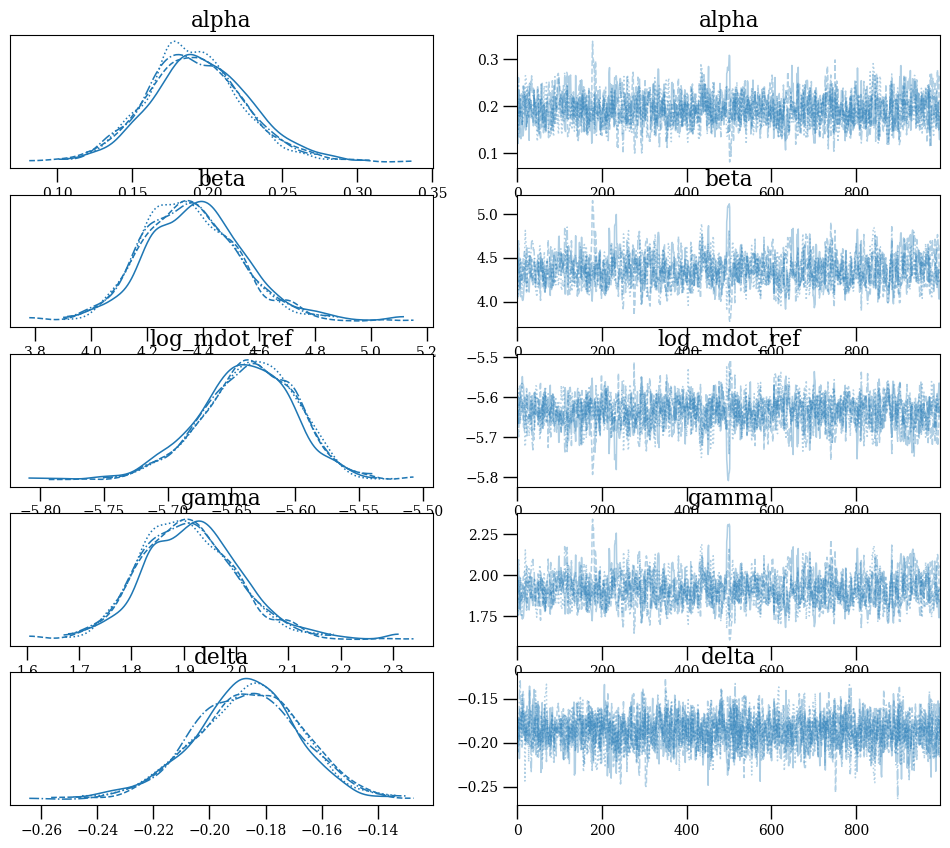

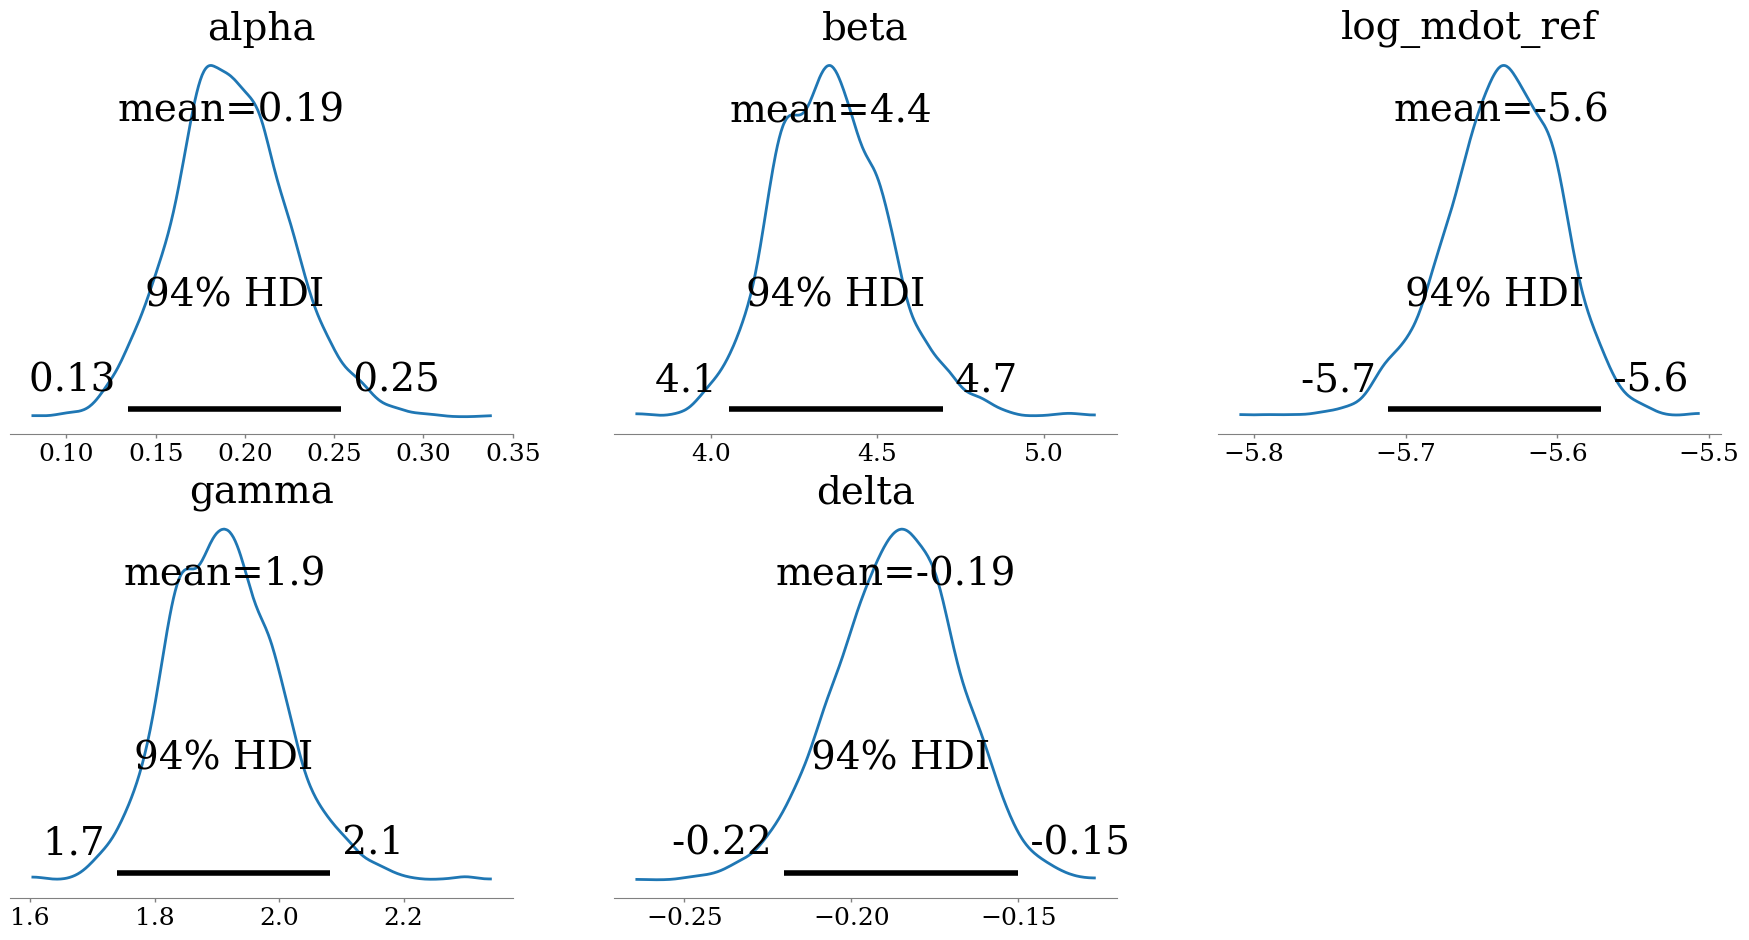

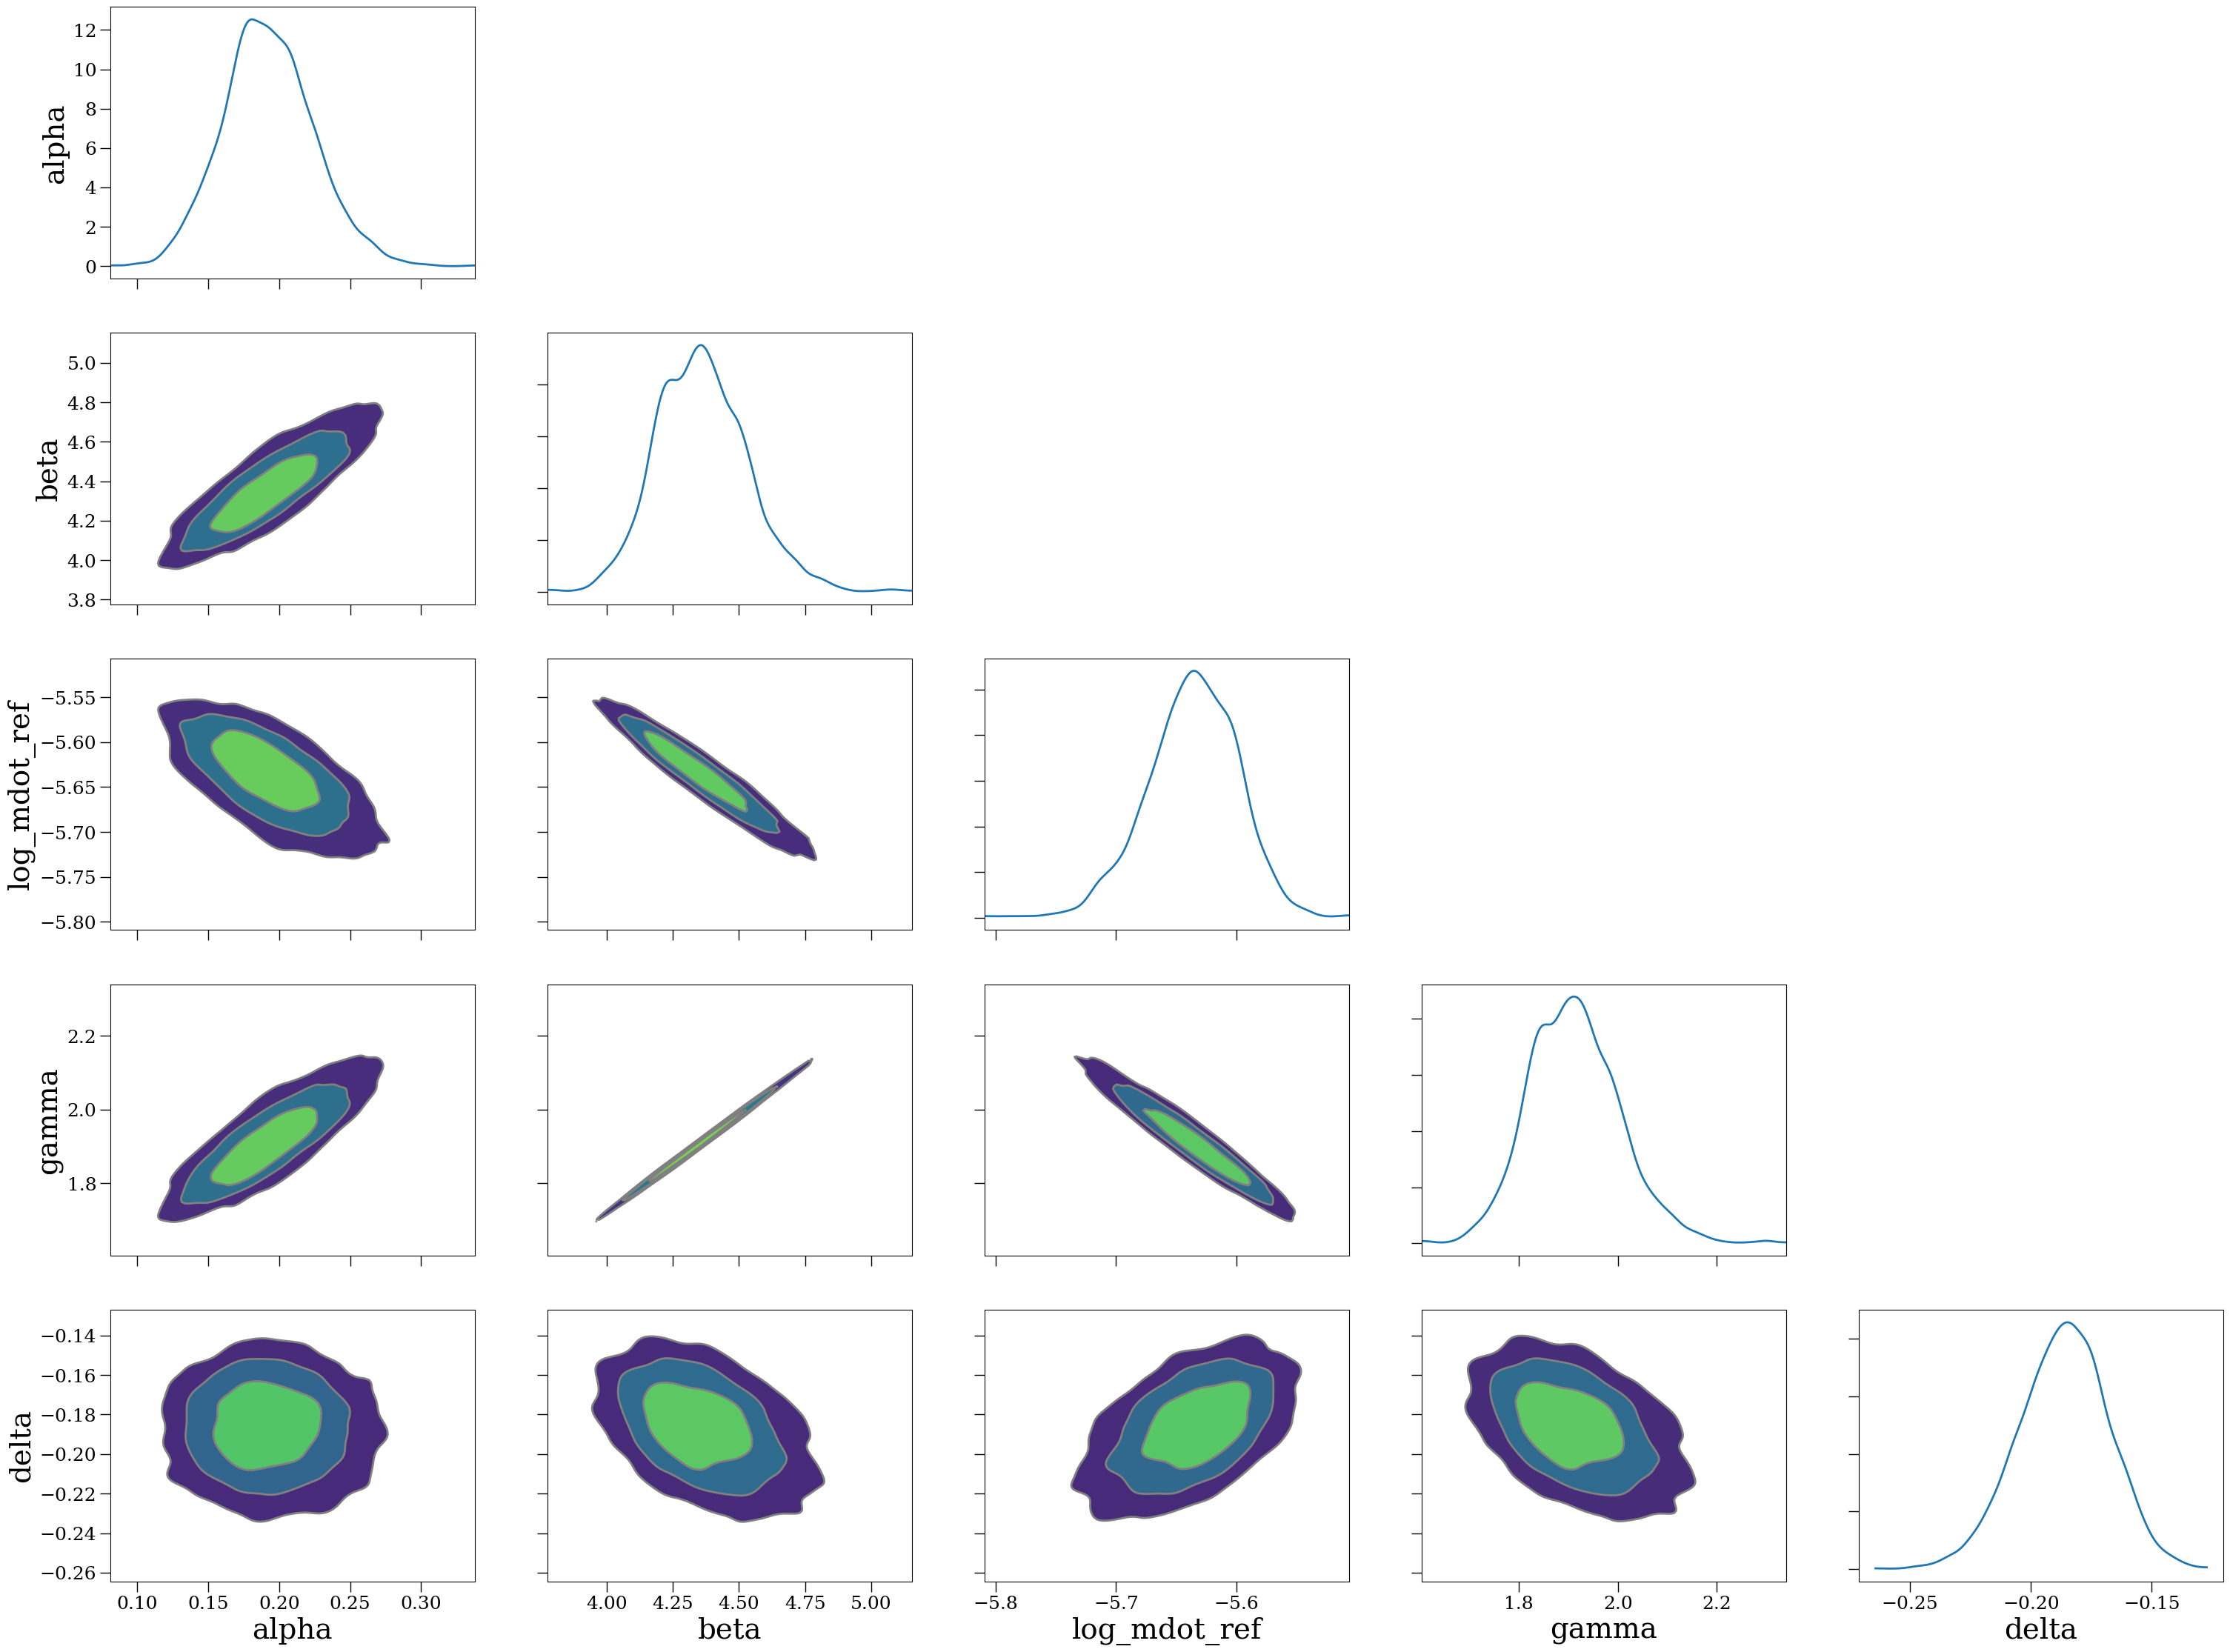

In [56]:
physmodel.fit()

In [38]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

def plot_random_sparsity_benchmark(summary_df, out_path=None, show=True):
    """
    Plots the results of Experiment 1: Random Sparsity.
    Requires the `summary_df` containing mean and std for RMSE and NaN fractions.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Sort by fraction descending (1.0 to 0.05)
    df = summary_df.sort_values('train_frac', ascending=False)
    x = df['train_frac'] * 100 # Convert to percentage

    # --- Panel 1: RMSE Comparison ---
    ax1.plot(x, df['phys_rmse_mean'], marker='o', label='Physical Model', color='blue', linewidth=2)
    ax1.fill_between(x, df['phys_rmse_mean'] - df['phys_rmse_std'], 
                     df['phys_rmse_mean'] + df['phys_rmse_std'], color='blue', alpha=0.2)
    
    ax1.plot(x, df['interp_rmse_mean'], marker='s', label='Linear Interpolator', color='red', linestyle='--', linewidth=2)
    ax1.fill_between(x, df['interp_rmse_mean'] - df['interp_rmse_std'], 
                     df['interp_rmse_mean'] + df['interp_rmse_std'], color='red', alpha=0.2)

    ax1.invert_xaxis()  # Read left-to-right as data gets sparser
    ax1.set_xlabel('Training Data Fraction (%)')
    ax1.set_ylabel('RMSE ($M_{\odot}$)')
    ax1.set_title('Model Robustness to Random Sparsity')
    ax1.grid(True, linestyle=':', alpha=0.6)
    ax1.legend()

    # --- Panel 2: Interpolator Failure Rate ---
    ax2.plot(x, df['interp_nan_frac_mean'] * 100, marker='x', color='darkred', linewidth=2)
    ax2.fill_between(x, (df['interp_nan_frac_mean'] - df['interp_nan_frac_std']) * 100, 
                     (df['interp_nan_frac_mean'] + df['interp_nan_frac_std']) * 100, color='darkred', alpha=0.2)
    
    ax2.invert_xaxis()
    ax2.set_xlabel('Training Data Fraction (%)')
    ax2.set_ylabel('Failure Rate (% NaNs)')
    ax2.set_title('Interpolator Topological Failures')
    ax2.grid(True, linestyle=':', alpha=0.6)

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=300)
    
    if show:
        plt.show()
        
    return fig


def plot_structured_coarsening_benchmark(coarse_df, out_path=None, show=True):
    """
    Plots the results of Experiment 1B: Structured Grid Coarsening.
    Uses grouped bar charts to compare performance across discrete stride configurations.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    labels = coarse_df['stride_name'].tolist()
    x = np.arange(len(labels))
    width = 0.35

    # --- Panel 1: RMSE Comparison ---
    ax1.bar(x - width/2, coarse_df['phys_rmse'], width, label='Physical Model', color='blue', alpha=0.8)
    ax1.bar(x + width/2, coarse_df['interp_rmse'], width, label='Linear Interpolator', color='red', alpha=0.8)
    
    ax1.set_ylabel('RMSE ($M_{\odot}$)')
    ax1.set_title('Performance Degradation due to Grid Decimation')
    ax1.legend()
    ax1.grid(axis='y', linestyle=':', alpha=0.6)

    # --- Panel 2: Failure Rate & Grid Size ---
    ax2.bar(x, coarse_df['interp_nan_frac'] * 100, color='darkred', alpha=0.7, label='% Interpolator Fails (NaNs)')
    
    # Add a twin axis to show how small the grid is getting
    ax3 = ax2.twinx()
    ax3.plot(x, coarse_df['train_size'], color='black', marker='D', linestyle='-', linewidth=2, label='Grid Points')
    ax3.set_ylabel('Remaining Grid Points (Train Size)', color='black')
    ax3.set_yscale('log') # Log scale helps visualize dramatic grid reductions
    
    ax2.set_ylabel('Interpolator Failure Rate (%)', color='darkred')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    
    # Combine legends for the bottom plot
    lines, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax3.get_legend_handles_labels()
    ax2.legend(lines + lines2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    if out_path:
        plt.savefig(out_path, dpi=300)
        
    if show:
        plt.show()
        
    return fig


def plot_structured_extrapolation_spatial_residuals(test_df, phys_pred, interp_pred, z_slice=None, out_path=None, show=True):
    """
    Diagnostic plot for Experiment 2: Structured Extrapolation.
    Plots the spatial distribution of residuals on a 2D slice (Mass vs Period)
    to visually demonstrate where the interpolator fails vs where the physical model succeeds.
    """
    if z_slice is not None:
        # Filter to a specific metallicity for a clean 2D plot
        mask = np.isclose(test_df['z'], z_slice)
        df_slice = test_df[mask].copy()
        p_pred = phys_pred[mask]
        i_pred = interp_pred[mask]
    else:
        df_slice = test_df.copy()
        p_pred = phys_pred
        i_pred = interp_pred

    actual = df_slice['m_f'].values
    phys_resid = p_pred - actual
    interp_resid = i_pred - actual

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)

    # Calculate global color limits safely (handling potential all-NaN arrays)
    vmax_phys = np.nanmax(np.abs(phys_resid)) if not np.all(np.isnan(phys_resid)) else 0
    vmax_interp = np.nanmax(np.abs(interp_resid)) if not np.all(np.isnan(interp_resid)) else 0
    vmax = max(vmax_phys, vmax_interp)
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0  # Fallback if both are exactly 0 or completely NaN
    
    # --- Panel 1: Physical Model Residuals ---
    ax1.scatter(df_slice['m_zams'], df_slice['p_spin_zams'], 
                c=phys_resid, cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=50, edgecolor='k', alpha=0.8)
    ax1.set_title('Physical Model Error Residuals\n(Sane Extrapolation)')
    ax1.set_xlabel('Initial Mass ($M_{\odot}$)')
    ax1.set_ylabel('Initial Spin Period (Days)')
    
    # --- Panel 2: Interpolator Residuals (highlights NaNs) ---
    # Plot NaNs as distinct black crosses to show extrapolation breakdown
    nan_mask = np.isnan(interp_resid)
    if np.any(nan_mask):
        ax2.scatter(df_slice['m_zams'][nan_mask], df_slice['p_spin_zams'][nan_mask], 
                    color='black', marker='x', s=60, label='Failed to Interpolate (NaN)')
        ax2.legend()
    
    if not np.all(nan_mask):
        ax2.scatter(df_slice['m_zams'][~nan_mask], df_slice['p_spin_zams'][~nan_mask], 
                    c=interp_resid[~nan_mask], cmap='RdBu_r', vmin=-vmax, vmax=vmax, s=50, edgecolor='k', alpha=0.8)
    ax2.set_title('Interpolator Error Residuals\n(Boundary Failures)')
    ax2.set_xlabel('Initial Mass ($M_{\odot}$)')

    # Create a robust, independent colorbar using a ScalarMappable
    norm = plt.Normalize(vmin=-vmax, vmax=vmax)
    sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=norm)
    sm.set_array([])
    
    cbar = fig.colorbar(sm, ax=[ax1, ax2], orientation='vertical', shrink=0.9, pad=0.03)
    cbar.set_label('Prediction Error (Pred - True) [$M_{\odot}$]')

    if out_path:
        plt.savefig(out_path, dpi=300)
        
    if show:
        plt.show()
        
    return fig

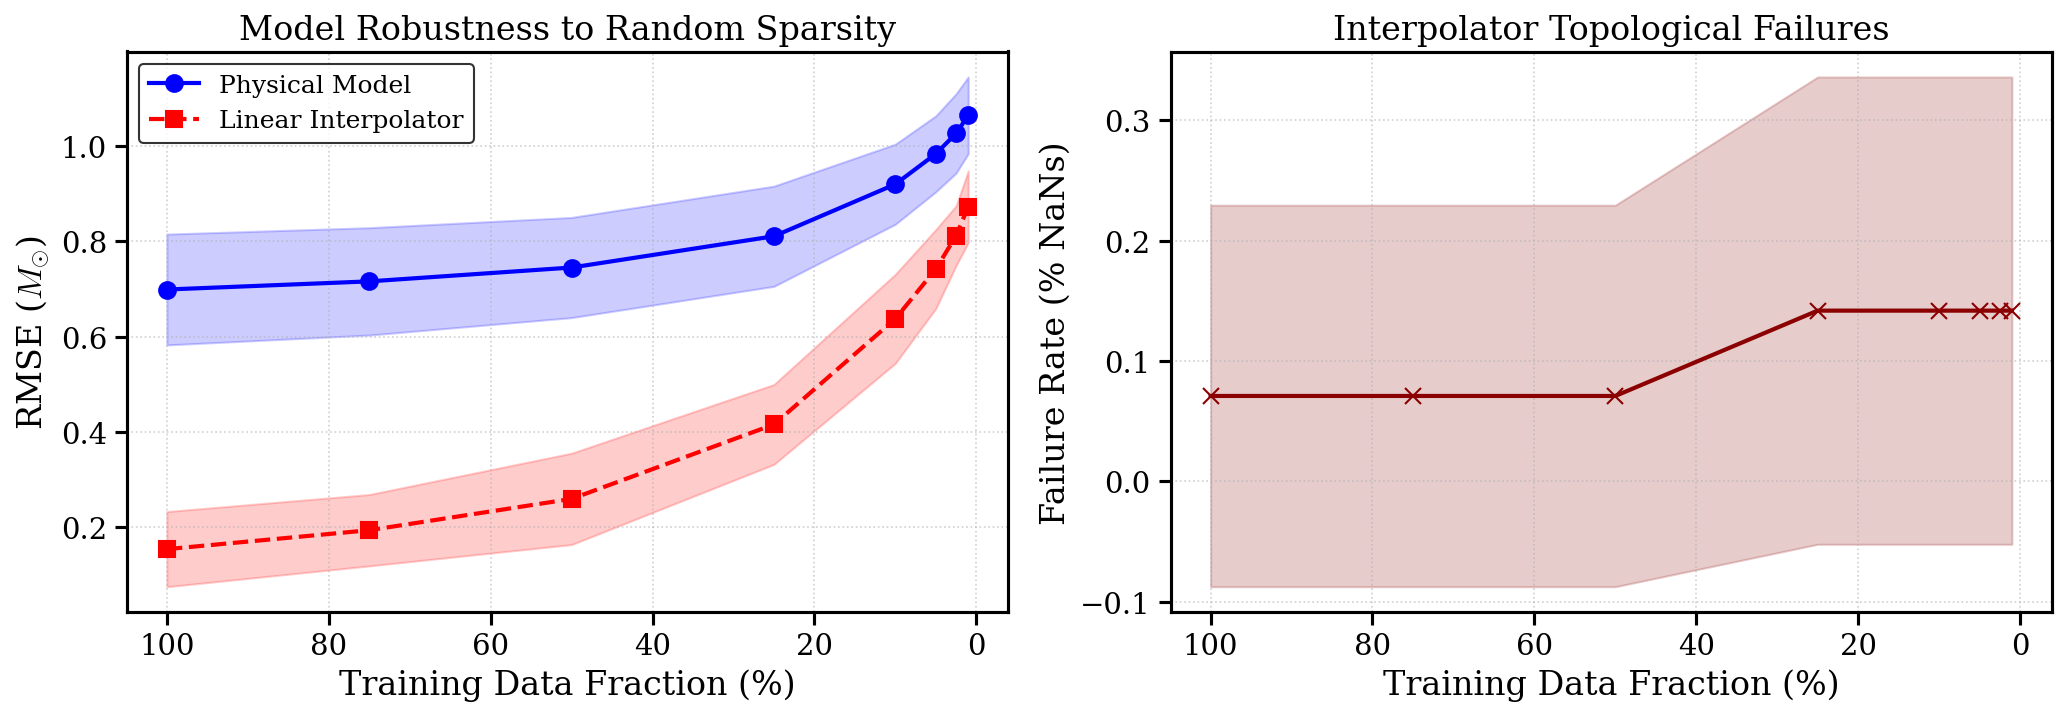

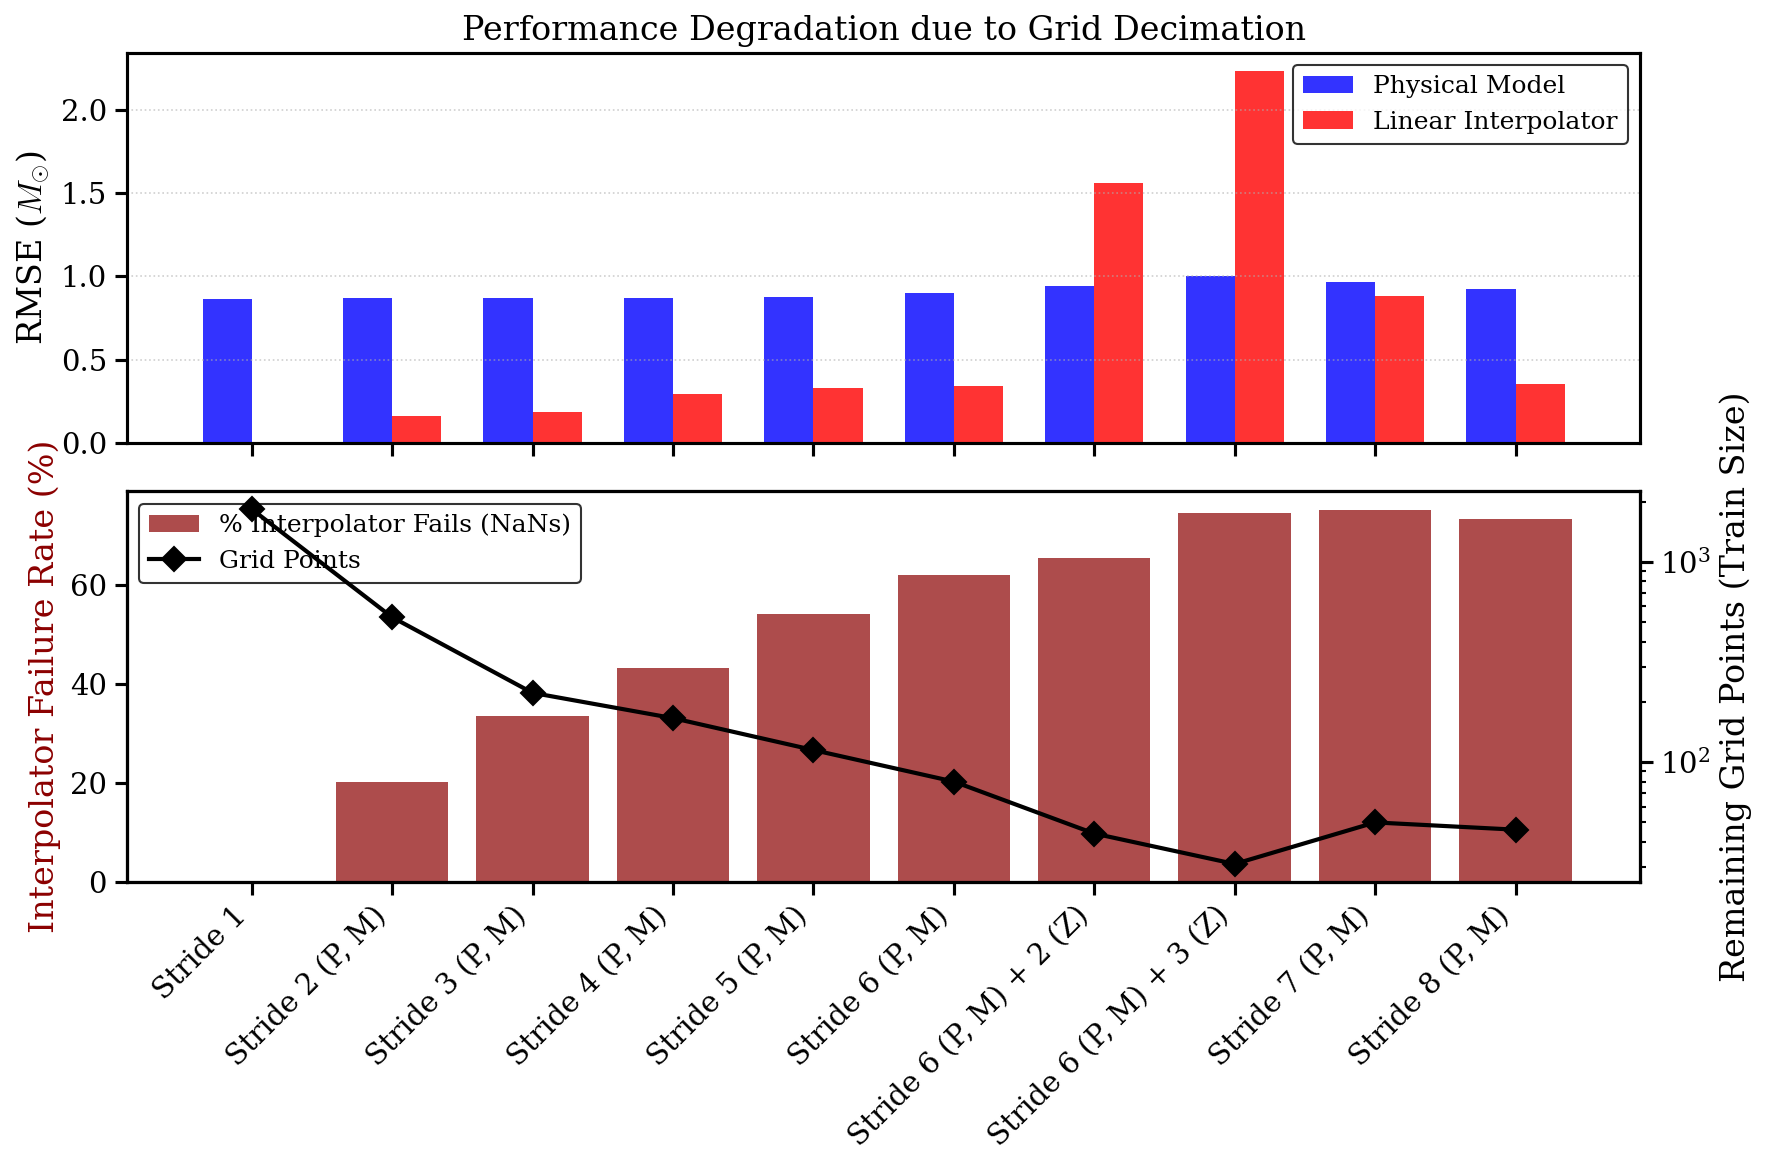

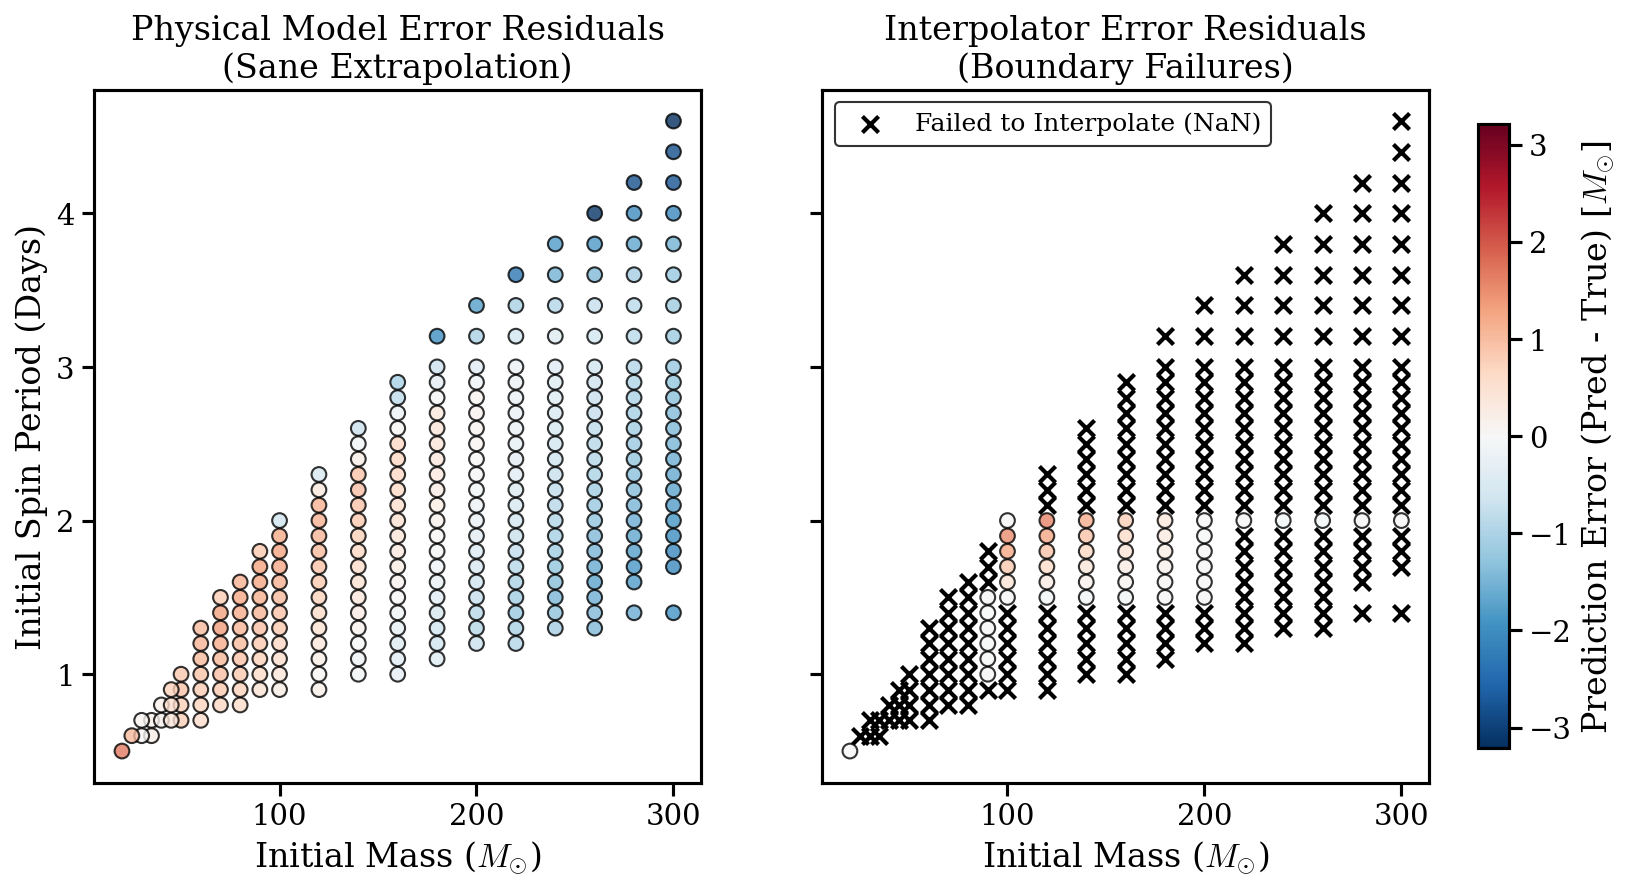

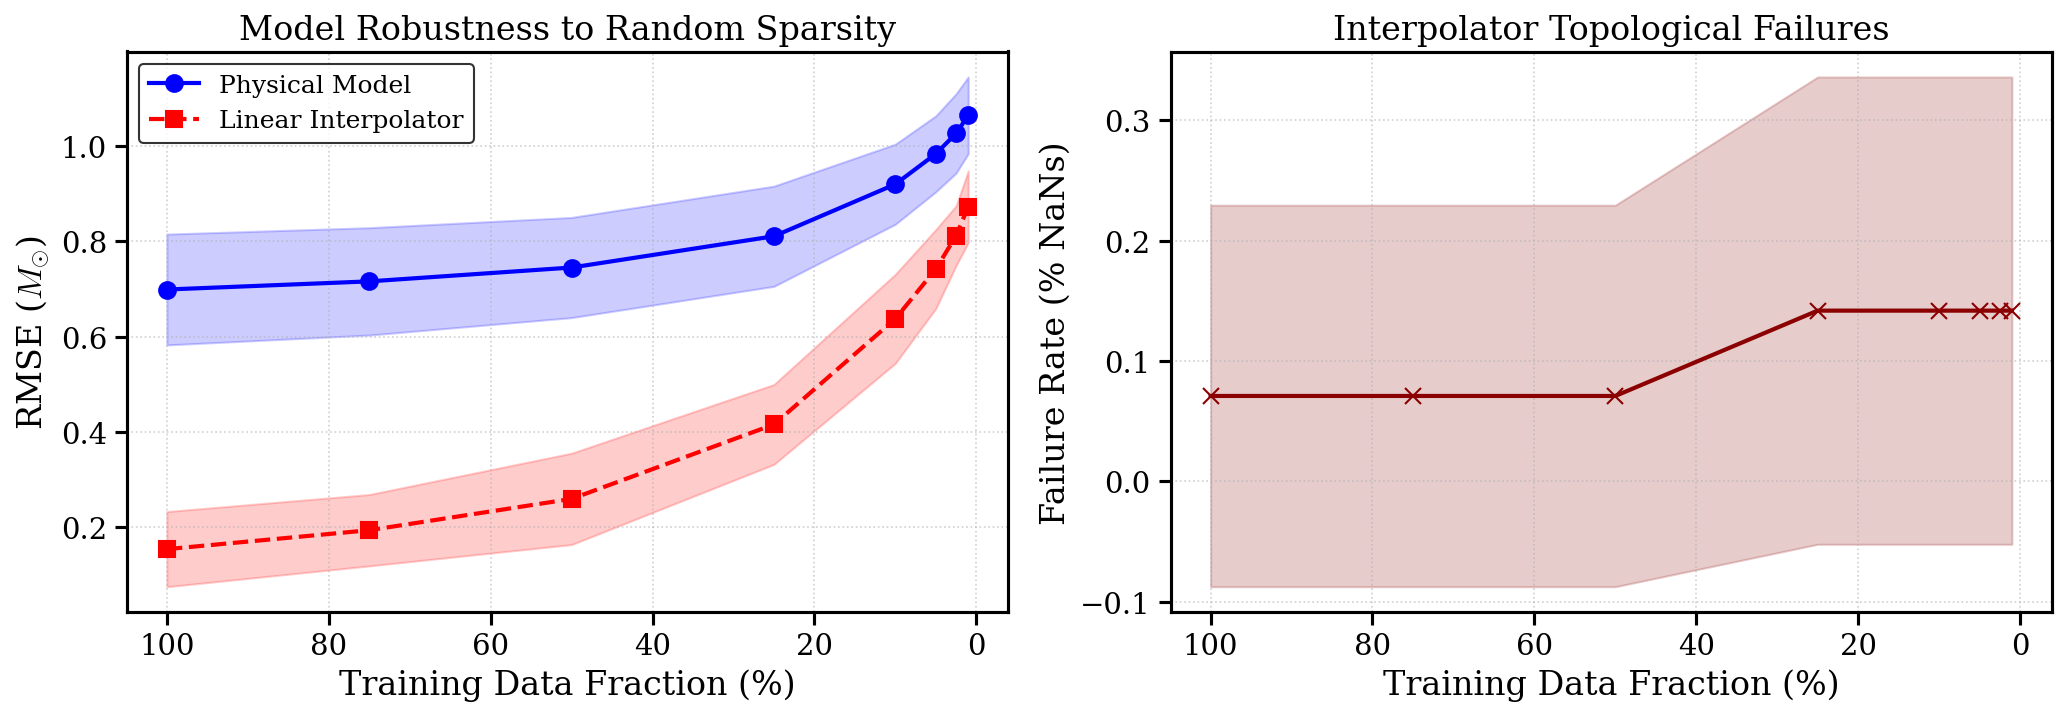

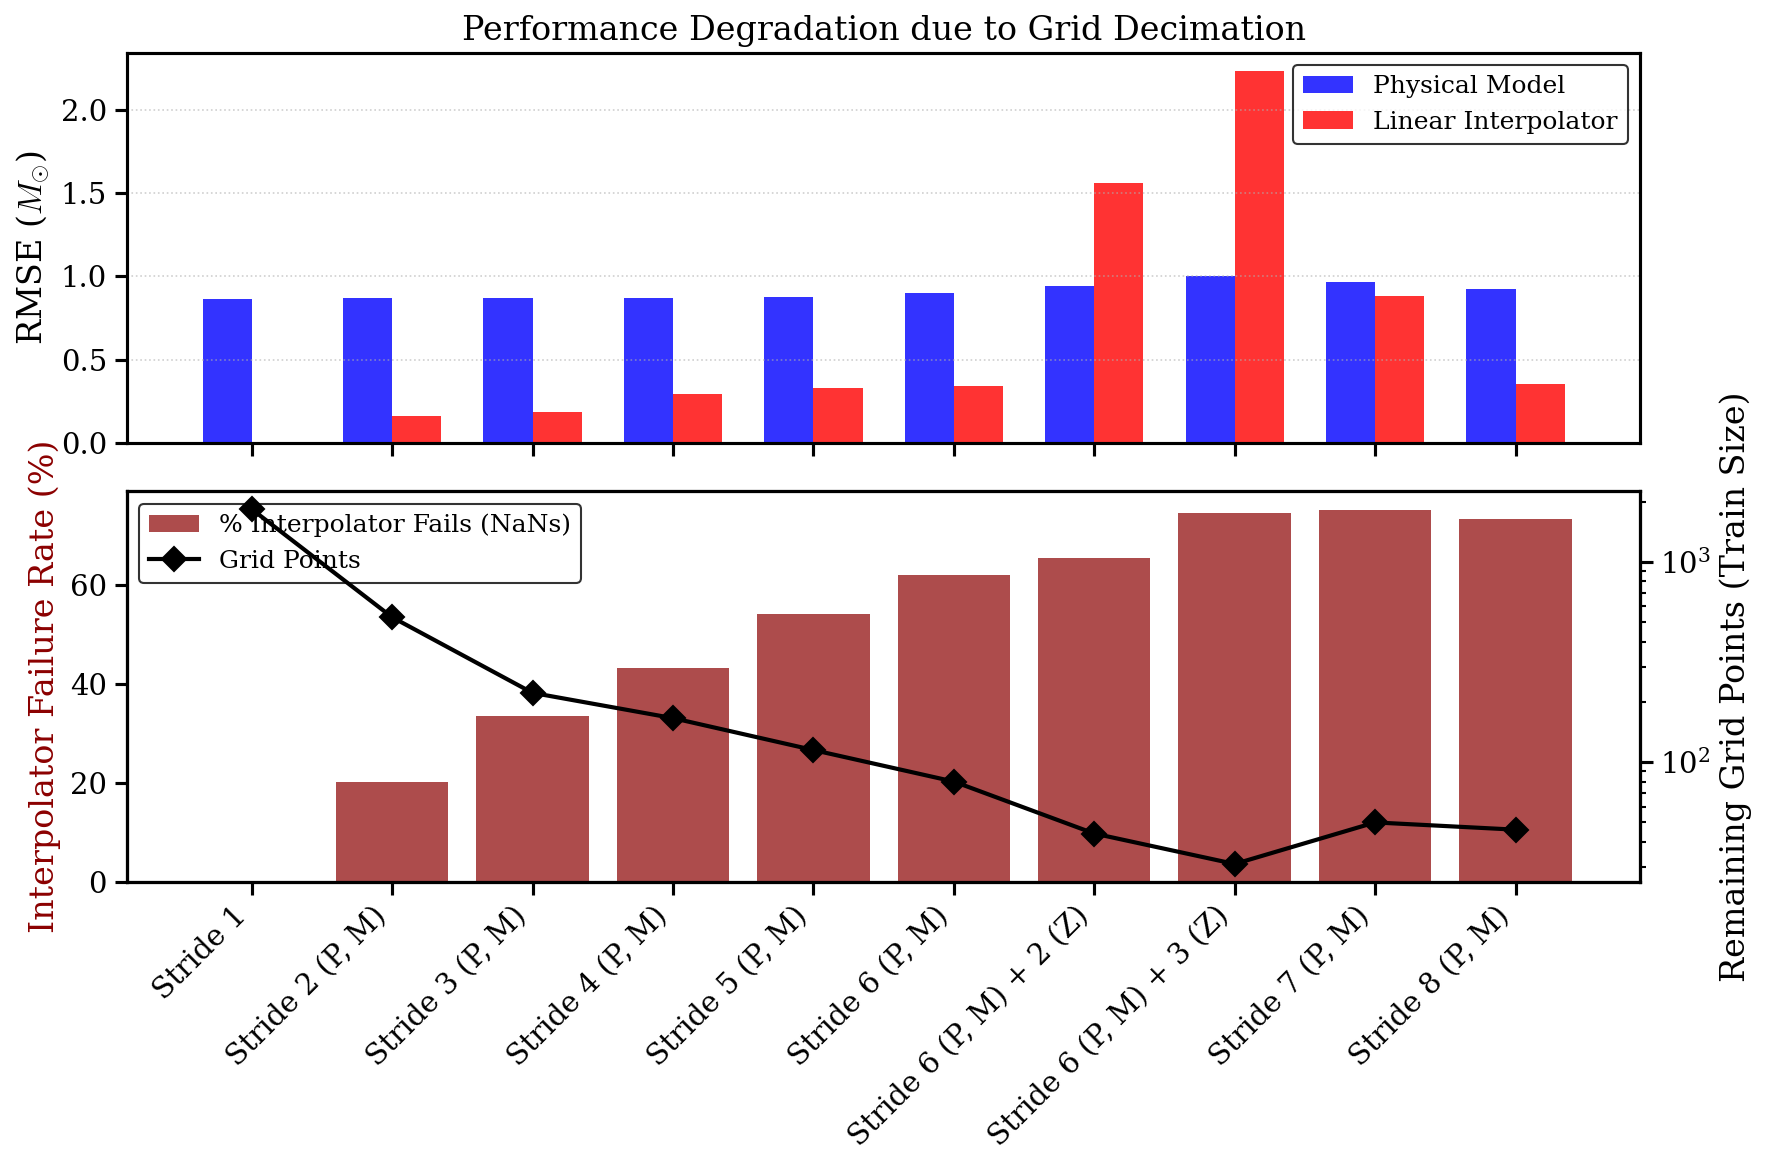

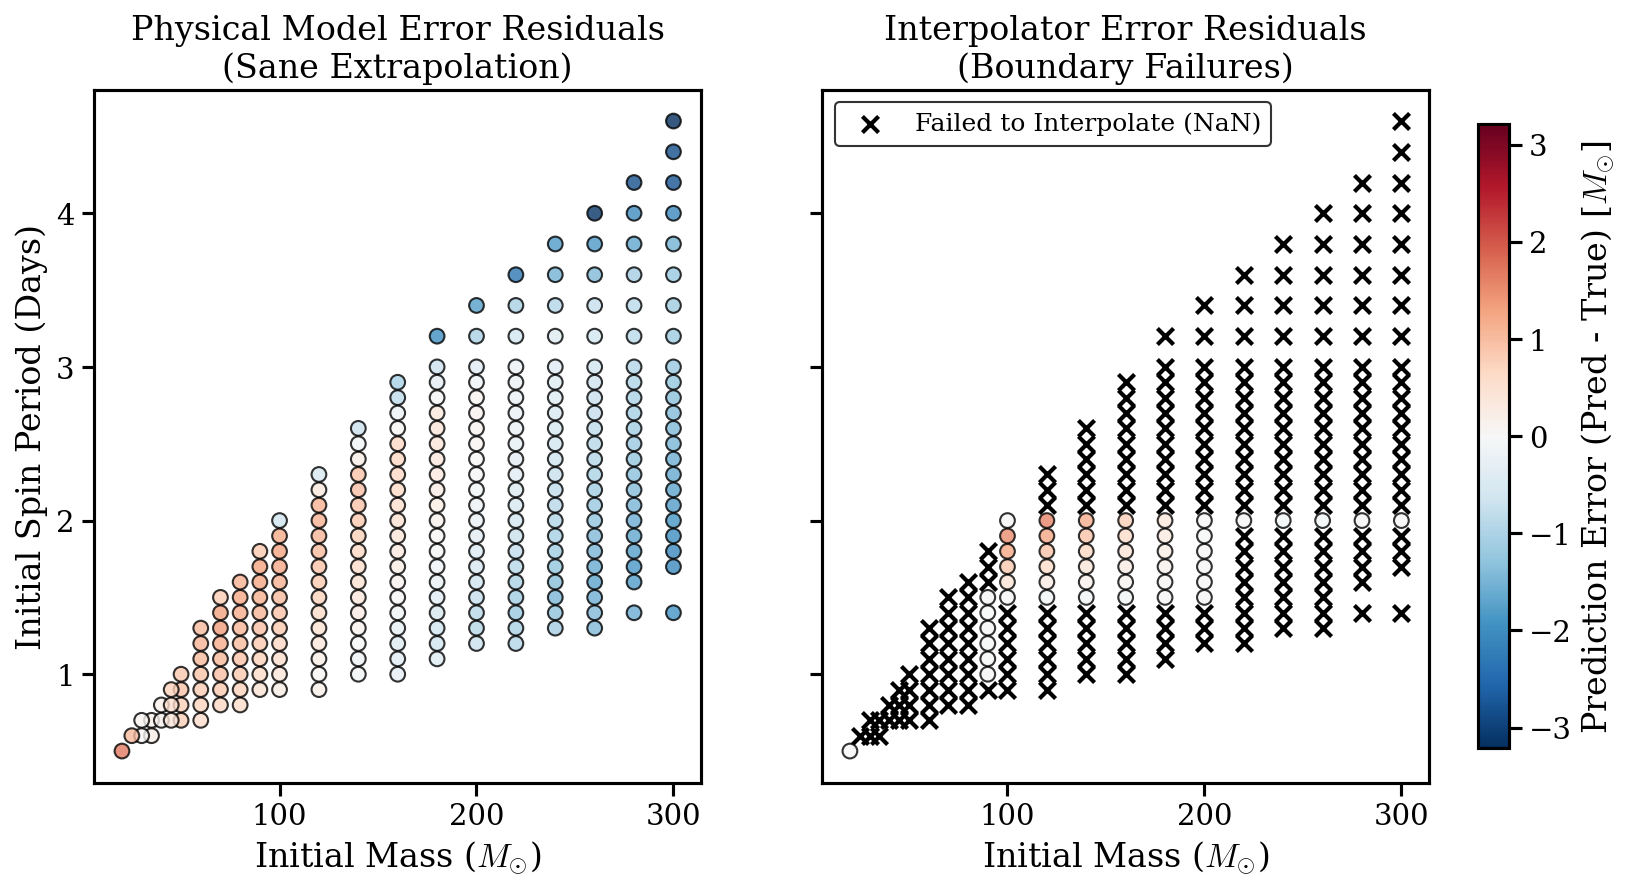

In [42]:
import joblib

out_dir = OUTPUT_FOLDER / f'benchmark_{run_id}'
work_df = working_che_core_props_df

# Load the stored models from disk
phys_model = joblib.load(out_dir / "extrap_phys_model.pkl")
interp_model = joblib.load(out_dir / "extrap_interp_model.pkl")

# ---------------------------------------------------------
# 1. Random Sparsity Benchmark
# ---------------------------------------------------------
summary_df = pd.read_csv(out_dir / 'random_sparse_summary.csv') 

fig_random = plot_random_sparsity_benchmark(summary_df, show=False)
display(fig_random) 

# ---------------------------------------------------------
# 2. Structured Coarsening Benchmark
# ---------------------------------------------------------
coarse_df = pd.read_csv(out_dir / 'coarsening_results.csv')

fig_coarsening = plot_structured_coarsening_benchmark(coarse_df, show=False)
display(fig_coarsening)

# ---------------------------------------------------------
# 3. Structured Extrapolation (Spatial Residuals)
# ---------------------------------------------------------
# Since eval.py doesn't save the raw predictions to disk, we generate 
# them dynamically using the models returned by evaluate_structured_sparse_test

# NOTE: This assumes `work_df`, `phys_model`, and `interp_model` are currently 
# in your notebook's memory (e.g., returned from the eval module).

# 1. Generate Physical Model Predictions
phys_pred, _ = phys_model.get_mf_logtd(
    work_df['m_zams'].values, 
    work_df['p_spin_zams'].values, 
    work_df['z'].values
)

# 2. Generate Interpolator Predictions
interp_pred = []
for _, row in work_df.iterrows():
    try:
        val = interp_model.get_var(row['m_zams'], row['p_spin_zams'], row['z'])
        interp_pred.append(float(val))
    except Exception:
        interp_pred.append(np.nan)
interp_pred = np.array(interp_pred)

# 3. Plot the Extrapolation residuals
fig_extrap = plot_structured_extrapolation_spatial_residuals(
    test_df=work_df, 
    phys_pred=phys_pred, 
    interp_pred=interp_pred, 
    z_slice=0.1, # Adjust this to match a specific metallicity in your grid
    show=False
)
display(fig_extrap)